# HBV Constant Su_max Calibration

This notebook runs the constant-Su_max HBV model from `hbv_bmi_constant.py`. Knowing that our temperature-dpendent model gives a wide range of Su_max outputs, we wanted to test 1) whether Su_max changes at all in the temperature-independent HBV model and 2) how sensitive is Q on Su_max.  

In [34]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from hbv_bmi_constant import HBV_Bmi

In [35]:
# Put this at the top of your notebook/cell
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 26,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'lines.linewidth': 2.5,
    'lines.markersize': 9,
    'savefig.dpi': 300,
})

In [36]:
base = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')
temp_path = base / 'ERA5_Temp_1980_2026.csv'
precip_path = base / 'Moselle_ERA5_monthly_precip_1980-01-01_2026-02-28.csv'
evap_path = base / 'Moselle_ERA5_monthly_evap_1980-01-01_2026-02-28.csv'
grdc_path = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')
shape_area = 28191724718  # m2

In [38]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from hbv_bmi_constant import HBV_Bmi  # absolute import (namespace package-safe)

# ----------------------------
# Utilities
# ----------------------------
def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    den = np.sum((obs - np.mean(obs)) ** 2)
    if den <= 0:
        return np.nan
    return 1 - np.sum((obs - sim) ** 2) / den

def load_forcing_daily(base_path: Path, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    precip = pd.read_csv(base_path / "ERA5_daily_precip_1980-2025.csv")
    evap = pd.read_csv(base_path / "ERA5_daily_evap_1980-2025.csv")

    for frame in (precip, evap):
        frame["time"] = pd.to_datetime(frame["system:index"].astype(str), format="%Y%m%d")
        frame.set_index("time", inplace=True)

    precip["total_precipitation_daily"] = pd.to_numeric(
        precip["total_precipitation_daily"], errors="coerce"
    ).replace(-9999, np.nan)
    evap["total_evaporation_daily"] = pd.to_numeric(
        evap["total_evaporation_daily"], errors="coerce"
    ).replace(-9999, np.nan)

    idx = pd.date_range(start, end, freq="D")
    df = pd.DataFrame(index=idx)
    df["pr_mm_day"] = precip["total_precipitation_daily"].reindex(idx) * 1000.0
    df["pet_mm_day"] = (-evap["total_evaporation_daily"].reindex(idx)).clip(lower=0) * 1000.0

    df["pr_mm_day"] = df["pr_mm_day"].interpolate(limit_direction="both")
    df["pet_mm_day"] = df["pet_mm_day"].interpolate(limit_direction="both")
    return df

def load_q_obs_mm_day(grdc_path: Path, index: pd.DatetimeIndex, shape_area: float) -> np.ndarray:
    grdc = pd.read_csv(
        grdc_path,
        encoding="latin-1",
        sep=";",
        skiprows=36,
        index_col=0,
        parse_dates=True,
        usecols=[0, 2],
    )
    grdc.columns = ["q_m3s"]
    grdc["q_m3s"] = pd.to_numeric(grdc["q_m3s"], errors="coerce").replace(-999, np.nan)

    q_mm_day = (
        grdc["q_m3s"]
        .reindex(index)
        .interpolate(limit_direction="both")
        .to_numpy(dtype=float)
        * 86400.0 / shape_area * 1000.0
    )
    return q_mm_day

def write_forcing_netcdf(run_dir: Path, tag: str, index: pd.DatetimeIndex, pr: np.ndarray, pet: np.ndarray):
    pr_ds = xr.Dataset({"pr": ("time", np.asarray(pr, dtype=float))}, coords={"time": index})
    pet_ds = xr.Dataset({"evspsblpot": ("time", np.asarray(pet, dtype=float))}, coords={"time": index})

    pr_path = run_dir / f"tmp_pr_{tag}.nc"
    pet_path = run_dir / f"tmp_pet_{tag}.nc"
    pr_ds.to_netcdf(pr_path, mode="w")
    pet_ds.to_netcdf(pet_path, mode="w")
    return pr_path, pet_path

def run_hbv_constant(params: np.ndarray, pr_path: Path, pet_path: Path, run_dir: Path, tag: str) -> np.ndarray:
    cfg = {
        "precipitation_file": str(pr_path),
        "potential_evaporation_file": str(pet_path),
        "parameters": ",".join([f"{v:.10f}" for v in params]),
        "initial_storage": "0.0,100.0,0.0,5.0",
    }
    cfg_path = run_dir / f"tmp_cfg_{tag}.json"
    with open(cfg_path, "w") as f:
        json.dump(cfg, f)

    m = HBV_Bmi()
    m.initialize(str(cfg_path))

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0], dtype=float)
        m.get_value("Q", out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    return sim

def log_nse(obs, sim, eps=1e-6):
    obs = np.maximum(np.asarray(obs, dtype=float), eps)
    sim = np.maximum(np.asarray(sim, dtype=float), eps)
    return nse(np.log(obs), np.log(sim))

def rel_bias(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    s_obs = np.sum(obs)
    if s_obs == 0:
        return np.nan
    return (np.sum(sim) - s_obs) / s_obs

def combined_score(obs, sim, w_nse=0.45, w_lognse=0.35, w_bias=0.20):
    a = nse(obs, sim)
    b = log_nse(obs, sim)
    c = rel_bias(obs, sim)
    if not (np.isfinite(a) and np.isfinite(b) and np.isfinite(c)):
        return np.nan
    return w_nse * a + w_lognse * b - w_bias * abs(c)

## Decadal Su_max Estimation (HVE parameter calibration)

This section calibrates the constant-Su_max HBV model separately for each decade using only a calibration window (no validation split).

Spin-up handling used here:
- Each decade is scored on January 1 of year Y to December 31 of year Y+9.
- The model is initialized one year earlier when data are available, and that spin-up year is not included in scoring.
- For the first available decade, if a full 1-year pre-decade period is not available, spin-up is shorter. Interpret that decade with extra caution.

In [ ]:
# Calibrate one constant Su_max per decade (no validation split)
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
import json
from tqdm.notebook import tqdm

base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))
shape_area_local = float(globals().get('shape_area', 28191724718.0))
grdc_path_local = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')

# Load stitched daily forcing (1980-2025)
precip_daily = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
evap_daily = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')

for frame in (precip_daily, evap_daily):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')
    frame.set_index('time', inplace=True)

precip_daily['total_precipitation_daily'] = pd.to_numeric(
    precip_daily['total_precipitation_daily'], errors='coerce'
).replace(-9999, np.nan)
evap_daily['total_evaporation_daily'] = pd.to_numeric(
    evap_daily['total_evaporation_daily'], errors='coerce'
).replace(-9999, np.nan)

forcing_all = pd.DataFrame(index=precip_daily.index.union(evap_daily.index).sort_values())
forcing_all['pr_mm_day'] = precip_daily['total_precipitation_daily'].reindex(forcing_all.index) * 1000.0
forcing_all['pet_mm_day'] = (-evap_daily['total_evaporation_daily'].reindex(forcing_all.index)).clip(lower=0) * 1000.0

forcing_all['pr_mm_day'] = forcing_all['pr_mm_day'].interpolate(limit_direction='both')
forcing_all['pet_mm_day'] = forcing_all['pet_mm_day'].interpolate(limit_direction='both')

# Load observed discharge and convert to mm/day
grdc_all = pd.read_csv(
    grdc_path_local,
    encoding='latin-1',
    sep=';',
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc_all.columns = ['q_m3s']
grdc_all['q_m3s'] = grdc_all['q_m3s'].replace(-999, np.nan) 

q_obs_mm_day = (
    grdc_all['q_m3s']
    .reindex(forcing_all.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

all_data = forcing_all.copy()
all_data['q_obs_mm_day'] = q_obs_mm_day
all_data = all_data.dropna(subset=['pr_mm_day', 'pet_mm_day', 'q_obs_mm_day']).copy()

if all_data.empty:
    raise RuntimeError('No overlapping forcing and discharge data available for decadal calibration.')

ParMinn_mc = np.array([0.0, 0.2, 40.0, 0.5, 0.001, 0.0, 0.01, 0.0001])
ParMaxn_mc = np.array([9.0, 1.0, 800.0, 4.0, 0.3, 10.0, 0.5, 0.02])
param_names = ['Imax', 'Ce', 'Sumax0', 'beta', 'Pmax', 'Tlag', 'Kf', 'Ks']

N_mc_decade = 500 # not ideal, but capped at 500 for a realistic computation time

run_dir = Path.home() / 'tmp_hbv_constant'
run_dir.mkdir(parents=True, exist_ok=True)

first_year = int(all_data.index.min().year)
last_year = int(all_data.index.max().year)
decade_starts = list(range((first_year // 10) * 10, last_year + 1, 10))

decade_results = []

for decade_start in tqdm(decade_starts, desc='Decades', unit='decade'):
    decade_end = decade_start + 9
    score_start = max(pd.Timestamp(f'{decade_start}-01-01'), all_data.index.min())
    score_end = min(pd.Timestamp(f'{decade_end}-12-31'), all_data.index.max())

    if score_end <= score_start:
        continue

    sim_start = max(all_data.index.min(), score_start - pd.Timedelta(days=365))
    run_df = all_data.loc[sim_start:score_end].copy()
    if len(run_df) < 365:
        continue

    score_mask = (run_df.index >= score_start) & (run_df.index <= score_end)
    n_score_days = int(score_mask.sum())
    if n_score_days < 365 * 5:
        continue

    pr_ds = xr.Dataset({'pr': ('time', run_df['pr_mm_day'].to_numpy(dtype=float))}, coords={'time': run_df.index})
    pet_ds = xr.Dataset({'evspsblpot': ('time', run_df['pet_mm_day'].to_numpy(dtype=float))}, coords={'time': run_df.index})

    tag = f'{decade_start}_{pd.Timestamp.now().strftime("%Y%m%d_%H%M%S_%f")}'
    pr_path = run_dir / f'tmp_pr_decade_{tag}.nc'
    pet_path = run_dir / f'tmp_pet_decade_{tag}.nc'
    cfg_path = run_dir / f'tmp_cfg_decade_{tag}.json'

    pr_ds.to_netcdf(pr_path, mode='w')
    pet_ds.to_netcdf(pet_path, mode='w')

    obs_score = run_df.loc[score_mask, 'q_obs_mm_day'].to_numpy(dtype=float)
    best_run = None
    valid_runs = 0

    mc_iter = tqdm(
        range(N_mc_decade),
        desc=f'{decade_start}s MC',
        unit='run',
        leave=False,
    )
    for _ in mc_iter:
        p = np.random.uniform(ParMinn_mc, ParMaxn_mc)
        cfg = {
            'precipitation_file': str(pr_path),
            'potential_evaporation_file': str(pet_path),
            'parameters': ','.join([f'{v:.10f}' for v in p]),
            'initial_storage': '0.0,100.0,0.0,5.0',
        }
        with open(cfg_path, 'w') as f:
            json.dump(cfg, f)

        m = HBV_Bmi()
        m.initialize(str(cfg_path))

        sim = []
        while m.current_timestep < m.end_timestep:
            m.update()
            out = np.array([0.0])
            m.get_value('Q', out)
            sim.append(out[0])

        sim = np.asarray(sim, dtype=float)
        if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
            continue

        sim_score = sim[score_mask]
        if len(sim_score) != len(obs_score):
            continue

        nse_score = nse(obs_score, sim_score)
        lognse_score = log_nse(obs_score, sim_score)
        rb_score = rel_bias(obs_score, sim_score)
        if not (np.isfinite(nse_score) and np.isfinite(lognse_score) and np.isfinite(rb_score)):
            continue

        valid_runs += 1
        if (best_run is None) or (nse_score > best_run['nse_score']):
            best_run = {
                'params': p.copy(),
                'nse_score': float(nse_score),
                'lognse_score': float(lognse_score),
                'rb_score': float(rb_score),
            }

    if best_run is None:
        continue

    rec = {
        'decade': f'{decade_start}s',
        'score_start': score_start.date().isoformat(),
        'score_end': score_end.date().isoformat(),
        'sim_start': sim_start.date().isoformat(),
        'spinup_days': int((score_start - sim_start).days),
        'n_score_days': n_score_days,
        'valid_runs': valid_runs,
        'best_nse': best_run['nse_score'],
        'best_lognse': best_run['lognse_score'],
        'best_rel_bias': best_run['rb_score'],
    }
    for i, name in enumerate(param_names):
        rec[f'best_{name}'] = float(best_run['params'][i])
    rec['best_Su_max_mm'] = rec['best_Sumax0']

    decade_results.append(rec)

if not decade_results:
    raise RuntimeError('No decadal results produced. Check forcing/obs overlap or relax minimum score length.')

decadal_sumax_df = pd.DataFrame(decade_results)
decadal_sumax_df

Decades:   0%|          | 0/5 [00:00<?, ?decade/s]

1980s MC:   0%|          | 0/500 [00:00<?, ?run/s]

For continuity of workflow, previously calculated parameters are defined here:

In [48]:
import numpy as np
import pandas as pd
from pathlib import Path

if 'best_params_by_decade' not in globals():
    best_params_by_decade = pd.DataFrame({
    "decade": ["1980s", "1990s", "2000s", "2010s", "2020s"],
    "best_Imax": [7.9002, 7.5772, 2.1748, 4.3923, 3.0812],
    "best_Ce": [0.2917, 0.2797, 0.4554, 0.4151, 0.3918],
    "best_Sumax_mm": [127.9178, 230.6522, 276.5277, 277.5702, 294.4716],
    "best_beta": [1.6244, 1.5868, 2.6980, 2.3843, 0.8246],
    "best_Pmax": [0.1765, 0.1067, 0.2975, 0.1516, 0.2640],
    "best_Tlag": [2.9839, 2.2711, 6.7281, 3.8345, 1.8725],
    "best_Kf": [0.2338, 0.3467, 0.4462, 0.2618, 0.0208],
    "best_Ks": [0.0017, 0.0172, 0.0065, 0.0003, 0.0058],
})

base_path = Path("/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project")
grdc_path = Path("/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt")
shape_area = 28191724718.0
run_dir = Path.home() / "tmp_hbv_constant_tests"
run_dir.mkdir(parents=True, exist_ok=True)

decade_nse_results = []

for decade_label in best_params_by_decade["decade"]:
    decade_start = int(decade_label[:4])
    score_start = pd.Timestamp(f"{decade_start}-01-01")
    score_end = pd.Timestamp(f"{decade_start + 9}-12-31")
    sim_start = score_start - pd.Timedelta(days=365)

    forcing = load_forcing_daily(base_path, sim_start, score_end)
    q_obs_full = load_q_obs_mm_day(grdc_path, forcing.index, shape_area)
    score_mask = (forcing.index >= score_start) & (forcing.index <= score_end)

    row = best_params_by_decade.loc[best_params_by_decade["decade"] == decade_label].iloc[0]
    params = np.array([
        float(row["best_Imax"]),
        float(row["best_Ce"]),
        float(row["best_Sumax0"]),
        float(row["best_beta"]),
        float(row["best_Pmax"]),
        float(row["best_Tlag"]),
        float(row["best_Kf"]),
        float(row["best_Ks"]),
    ], dtype=float)

    pr_path, pet_path = write_forcing_netcdf(
        run_dir=run_dir,
        tag=f"{decade_label}_recalc",
        index=forcing.index,
        pr=forcing["pr_mm_day"].to_numpy(dtype=float),
        pet=forcing["pet_mm_day"].to_numpy(dtype=float),
    )

    sim_full = run_hbv_constant(params, pr_path, pet_path, run_dir, tag=f"{decade_label}_recalc")
    obs = q_obs_full[score_mask]
    sim = sim_full[score_mask]

    globals()[f"obs_{decade_start}s"] = obs
    globals()[f"sim_{decade_start}s"] = sim

    nse_val = nse(obs, sim)
    decade_nse_results.append({"decade": decade_label, "NSE": nse_val})

decade_nse_df = pd.DataFrame(decade_nse_results)
best_params_by_decade = best_params_by_decade.drop(columns=["NSE"], errors="ignore").merge(decade_nse_df, on="decade", how="left")

best_params_by_decade

,decade,best_Imax,best_Ce,best_Sumax0,best_beta,best_Pmax,best_Tlag,best_Kf,best_Ks,NSE
0,1980s,7.9002,0.2917,127.9178,1.6244,0.1765,2.9839,0.2338,0.0017,0.796554
1,1990s,7.5772,0.2797,230.6522,1.5868,0.1067,2.2711,0.3467,0.0172,0.826395
2,2000s,2.1748,0.4554,276.5277,2.6980,0.2975,6.7281,0.4462,0.0065,0.776287
3,2010s,4.3923,0.4151,277.5702,2.3843,0.1516,3.8345,0.2618,0.0003,0.858739
4,2020s,3.0812,0.3918,294.4716,0.8246,0.2640,1.8725,0.0208,0.0058,-5.865451


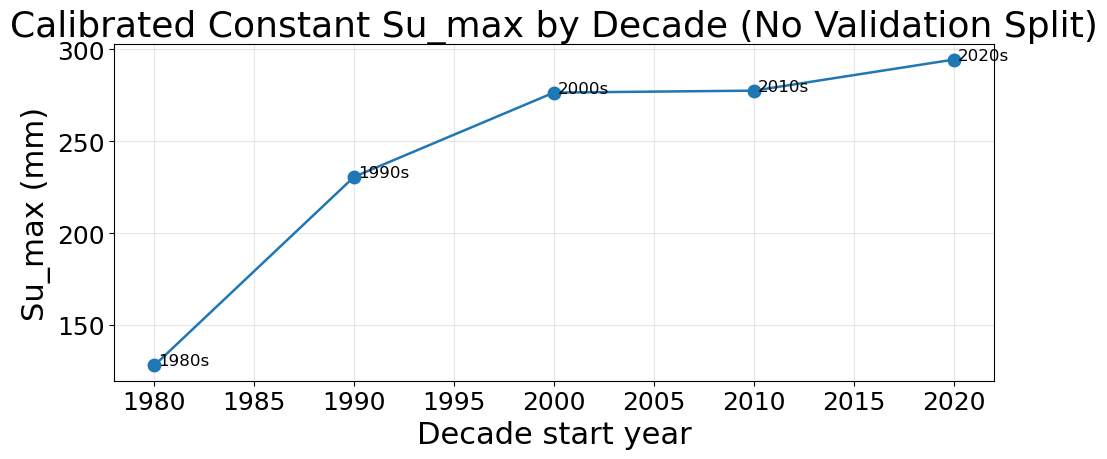

In [57]:
# Plot calibrated Su_max by decade
plot_df = best_params_by_decade.copy()
plot_df['decade_start_year'] = plot_df['decade'].str.replace('s', '', regex=False).astype(int)

fig, ax1 = plt.subplots(figsize=(10.5, 5))
ax1.plot(
    plot_df['decade_start_year'],
    plot_df['best_Sumax0'],
    marker='o',
    linewidth=1.8,
    label='Best Su_max (mm)'
)
ax1.set_xlabel('Decade start year')
ax1.set_ylabel('Su_max (mm)')
ax1.set_title('Calibrated Constant Su_max by Decade (No Validation Split)')
ax1.grid(alpha=0.3)

for _, r in plot_df.iterrows():
    ax1.text(r['decade_start_year'] + 0.2, r['best_Sumax0'], r['decade'], fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()

plt.tight_layout()
plt.show()

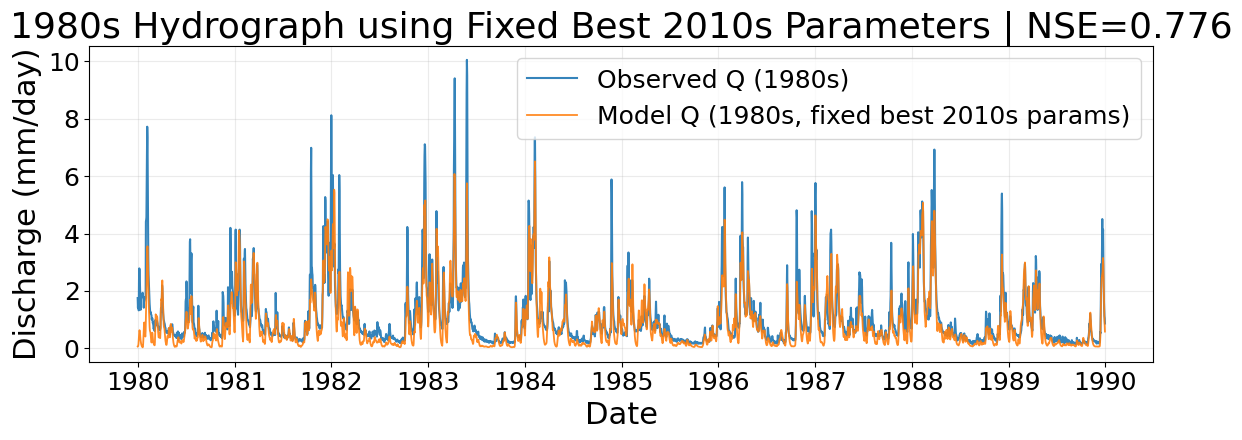

Used fixed 2010s params: [4.392300e+00 4.151000e-01 2.775702e+02 2.384300e+00 1.516000e-01
 3.834500e+00 2.618000e-01 3.000000e-04]
NSE (1980s with fixed 2010s params): 0.776390882235675


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Fixed best 2010s parameters from your decadal results:
# [Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks]
best_2010s_params = np.array([4.3923, 0.4151, 277.5702, 2.3843, 0.1516, 3.8345, 0.2618, 0.0003], dtype=float)

# 1980s run window (with 1-year spin-up)
sim_start_1980s = pd.Timestamp("1979-01-01")
sim_end_1980s = pd.Timestamp("1989-12-31")
score_start_1980s = pd.Timestamp("1980-01-01")
score_end_1980s = pd.Timestamp("1989-12-31")

base_path = Path("/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project")
grdc_path = Path("/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt")
shape_area = 28191724718.0
run_dir = Path.home() / "tmp_hbv_constant_tests"
run_dir.mkdir(parents=True, exist_ok=True)

# Reuse existing helper functions from your notebook
forcing_1980s = load_forcing_daily(base_path, sim_start_1980s, sim_end_1980s)
q_obs_1980s_full = load_q_obs_mm_day(grdc_path, forcing_1980s.index, shape_area)
score_mask_1980s = (forcing_1980s.index >= score_start_1980s) & (forcing_1980s.index <= score_end_1980s)

pr_1980s_path, pet_1980s_path = write_forcing_netcdf(
    run_dir=run_dir,
    tag="1980s_eval_fixed2010s",
    index=forcing_1980s.index,
    pr=forcing_1980s["pr_mm_day"].to_numpy(dtype=float),
    pet=forcing_1980s["pet_mm_day"].to_numpy(dtype=float),
)


sim_1980s_full = run_hbv_constant(
    best_2010s_params, pr_1980s_path, pet_1980s_path, run_dir, tag="1980s_with_fixed_2010s_best"
)

idx_1980s = forcing_1980s.index[score_mask_1980s]
obs_1980s = q_obs_1980s_full[score_mask_1980s]
sim_1980s = sim_1980s_full[score_mask_1980s]
nse_1980s_with_2010s = nse(obs_1980s, sim_1980s)

plt.figure(figsize=(12, 4.8))
plt.plot(idx_1980s, obs_1980s, label="Observed Q (1980s)", linewidth=1.5, alpha=0.9)
plt.plot(idx_1980s, sim_1980s, label="Model Q (1980s, fixed best 2010s params)", linewidth=1.3, alpha=0.9)
plt.title(f"1980s Hydrograph using Fixed Best 2010s Parameters | NSE={nse_1980s_with_2010s:.3f}")
plt.xlabel("Date")
plt.ylabel("Discharge (mm/day)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("Used fixed 2010s params:", best_2010s_params)
print("NSE (1980s with fixed 2010s params):", float(nse_1980s_with_2010s))

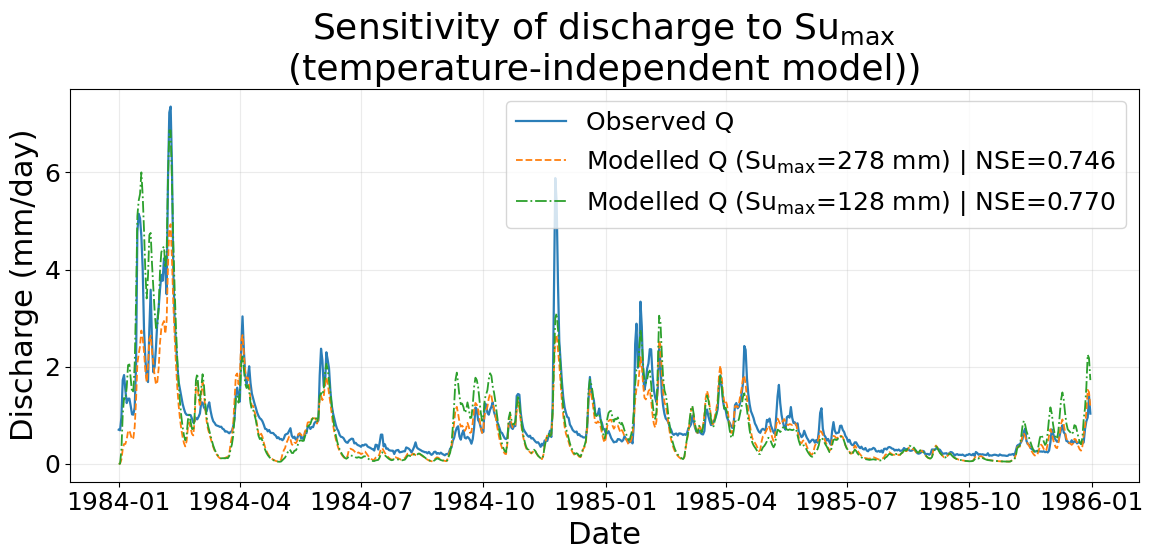

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if 'best_params_by_decade' not in globals():
    raise RuntimeError('Run the decadal parameter table cell first.')

row_1980s = best_params_by_decade.loc[best_params_by_decade['decade'] == '1980s'].iloc[0]

# Best 1980s parameters, but replace Sumax0 with 277.572
params_1980s_mod = np.array([
    float(row_1980s['best_Imax']),
    float(row_1980s['best_Ce']),
    277.572,  # replace Sumax0
    float(row_1980s['best_beta']),
    float(row_1980s['best_Pmax']),
    float(row_1980s['best_Tlag']),
    float(row_1980s['best_Kf']),
    float(row_1980s['best_Ks']),
], dtype=float)

# Full 1980s parameters from your table
params_1980s_full = np.array([
    float(row_1980s['best_Imax']),
    float(row_1980s['best_Ce']),
    float(row_1980s['best_Sumax0']),
    float(row_1980s['best_beta']),
    float(row_1980s['best_Pmax']),
    float(row_1980s['best_Tlag']),
    float(row_1980s['best_Kf']),
    float(row_1980s['best_Ks']),
], dtype=float)

sim_start_1980s = pd.Timestamp("1984-01-01")
sim_end_1980s = pd.Timestamp("1985-12-31")
score_start_1980s = pd.Timestamp("1984-01-01")
score_end_1980s = pd.Timestamp("1985-12-31")

base_path = Path("/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project")
grdc_path = Path("/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt")
shape_area = 28191724718.0
run_dir = Path.home() / "tmp_hbv_constant_tests"
run_dir.mkdir(parents=True, exist_ok=True)

forcing_1980s = load_forcing_daily(base_path, sim_start_1980s, sim_end_1980s)
q_obs_1980s_full = load_q_obs_mm_day(grdc_path, forcing_1980s.index, shape_area)
score_mask_1980s = (forcing_1980s.index >= score_start_1980s) & (forcing_1980s.index <= score_end_1980s)

pr_1980s_path, pet_1980s_path = write_forcing_netcdf(
    run_dir=run_dir,
    tag="1980s_compare",
    index=forcing_1980s.index,
    pr=forcing_1980s["pr_mm_day"].to_numpy(dtype=float),
    pet=forcing_1980s["pet_mm_day"].to_numpy(dtype=float),
)

sim_1980s_mod_full = run_hbv_constant(
    params_1980s_mod, pr_1980s_path, pet_1980s_path, run_dir, tag="1980s_mod"
)
sim_1980s_full_full = run_hbv_constant(
    params_1980s_full, pr_1980s_path, pet_1980s_path, run_dir, tag="1980s_full"
)

idx_1980s = forcing_1980s.index[score_mask_1980s]
obs_1980s = q_obs_1980s_full[score_mask_1980s]
sim_1980s_mod = sim_1980s_mod_full[score_mask_1980s]
sim_1980s_full = sim_1980s_full_full[score_mask_1980s]

nse_mod = nse(obs_1980s, sim_1980s_mod)
nse_full = nse(obs_1980s, sim_1980s_full)

plt.figure(figsize=(12, 6))
plt.plot(idx_1980s, obs_1980s, label="Observed Q", linewidth=1.6, alpha=0.95)
plt.plot(idx_1980s, sim_1980s_mod, label=f"Modelled Q ($\mathrm{{Su}}_{{\max}}$=278 mm) | NSE={nse_mod:.3f}", linewidth=1.3, linestyle='--')
plt.plot(idx_1980s, sim_1980s_full, label=f"Modelled Q ($\mathrm{{Su}}_{{\max}}$=128 mm) | NSE={nse_full:.3f}", linewidth=1.3, linestyle='-.')

plt.title("Sensitivity of discharge to $\mathrm{Su_{max}}$ \n(temperature-independent model))")
plt.xlabel("Date")
plt.ylabel("Discharge (mm/day)")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()